> **Group:** Sara Martinez Rendon (1000424179) | Heider Zapata (1000009586) | Yeison Londoño (1000009479)  
> **Master's Degree in Data Sciences** | EAFIT University  
> **Course:** Applied Statistics   
> **Date:** 27/03/2026
---

# **Examen 3: Modelo de regresión**

---

## **Configuración del Entorno y Carga de Datos**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas para Inferencia y Diagnósticos (Pregunta 1)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

# Herramientas para Modelado Predictivo y LASSO (Pregunta 2)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Configuración de visualización
%matplotlib inline
sns.set(style="whitegrid")

# Definición de enlaces de descarga directa desde Google Drive
url_consumo = "https://drive.google.com/uc?id=1R0Uj-ws7OsCnekJ_IHB3OErVYRE-0vlM"
url_mantenimiento = "https://drive.google.com/uc?id=1VPTb7YgV2P4vk8m3BH7pJEmlDcPwi_ly"

# Carga de los datasets
try:
    df_consumo = pd.read_csv(url_consumo)
    df_mantenimiento = pd.read_csv(url_mantenimiento)
    print("Datasets cargados exitosamente.")
    print(f"Dimensiones Consumo Energía: {df_consumo.shape}")
    print(f"Dimensiones Flota Mantenimiento: {df_mantenimiento.shape}")
except Exception as e:
    print(f"Error al cargar los datos: {e}")

Datasets cargados exitosamente.
Dimensiones Consumo Energía: (800, 7)
Dimensiones Flota Mantenimiento: (500, 6)


---

## **Pregunta 1: Inferencia y Diagnóstico Econométrico**

### **1.1. Análisis preliminar de Correlación y Multicolinealidad**

Para comprender a fondo la estructura de nuestros datos antes de modelar, realizaremos un análisis exploratorio unificado que consta de dos partes:

1. **Matriz de Correlación Completa:** Transformaremos dinámicamente las variables categóricas (`tipo_ruta`, `plan_preventivo`) en variables *dummy* (0 y 1). Esto nos permitirá calcular tanto la correlación de Pearson (entre variables continuas) como la correlación punto-biserial (entre continuas y binarias), consolidando todas las relaciones en un solo mapa de calor.
2. **Gráficos de Dispersión (Pairplot):** Siguiendo la premisa del Cuarteto de Anscombe, no confiaremos solo en los números. Visualizaremos las relaciones bivariadas entre las variables continuas para identificar tendencias lineales, posibles relaciones no lineales y confirmar visualmente riesgos de multicolinealidad.

Esto nos permitirá anticipar qué variables serán significativas y si existe riesgo de redundancia entre ellas.

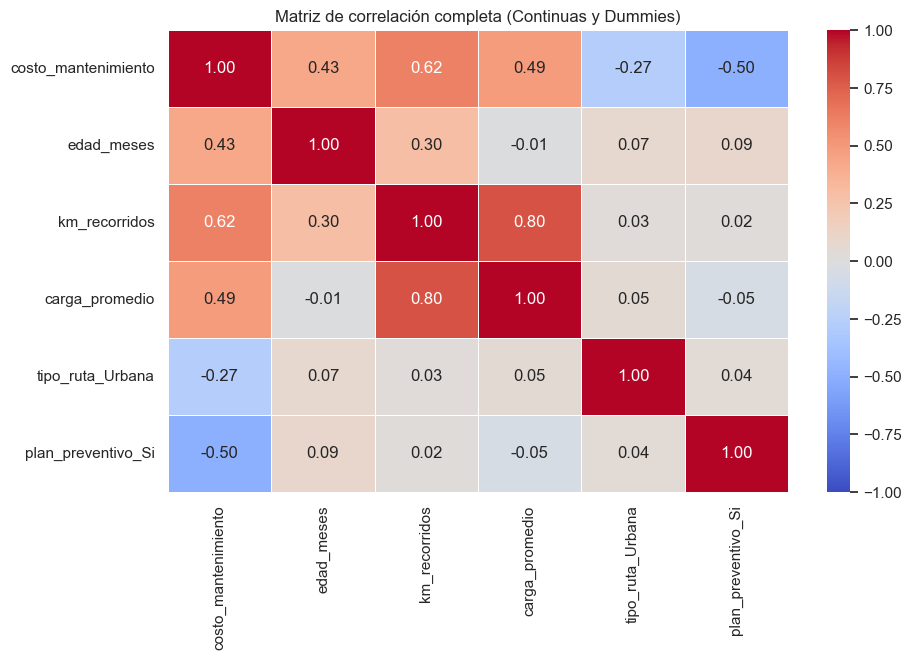

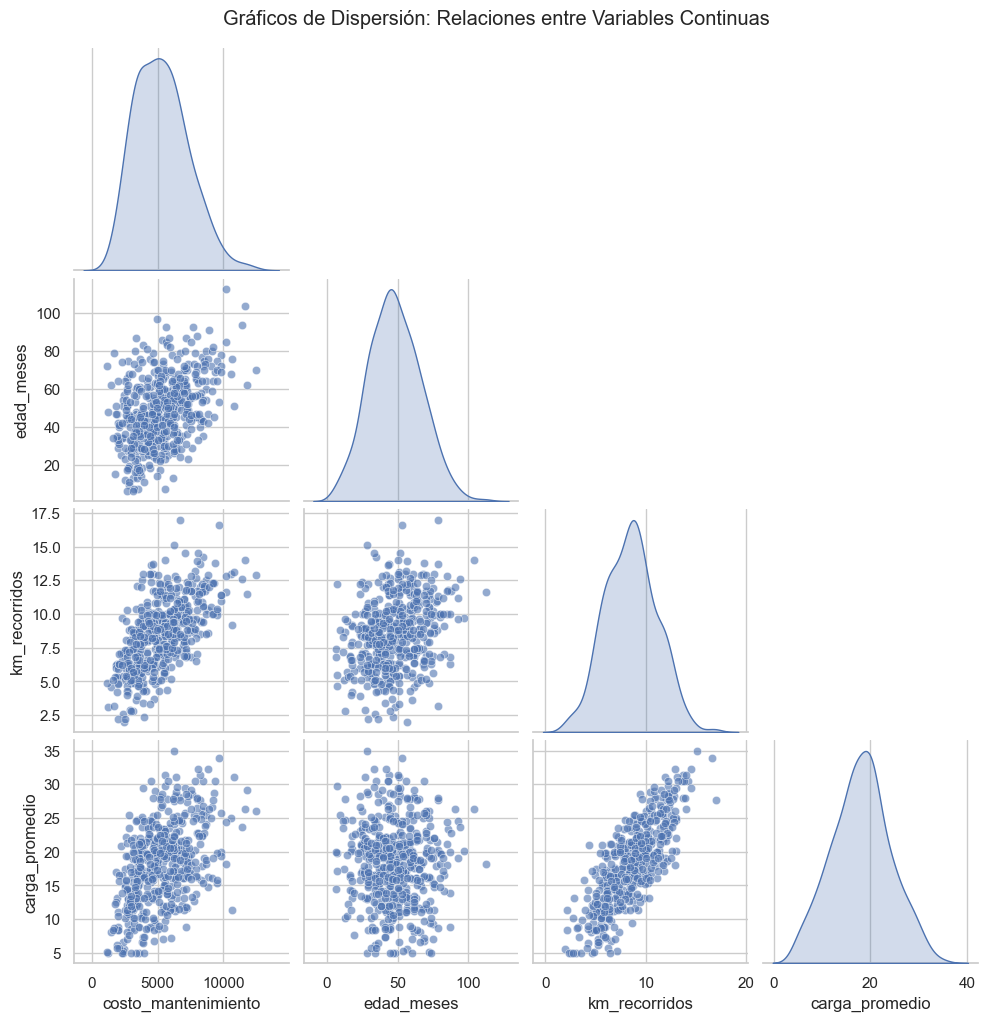

In [22]:
# ==============================================================================
# Análisis Exploratorio Unificado: Dummies, Correlación y Dispersión
# ==============================================================================

# 1. Transformación de Variables Categóricas
if 'tipo_ruta' in df_mantenimiento.columns:
    df_mantenimiento = pd.get_dummies(df_mantenimiento, columns=['tipo_ruta', 'plan_preventivo'], drop_first=True)
    # Limpiamos los nombres reemplazando espacios por guiones bajos
    df_mantenimiento.columns = [c.replace(' ', '_').replace('(', '').replace(')', '') for c in df_mantenimiento.columns]

# Identificamos los nombres exactos que pandas asignó a las nuevas columnas
col_ruta = [col for col in df_mantenimiento.columns if 'tipo_ruta' in col][0]
col_plan = [col for col in df_mantenimiento.columns if 'plan_preventivo' in col][0]

# 2. Matriz de Correlación Completa
cols_completas = ['costo_mantenimiento', 'edad_meses', 'km_recorridos', 'carga_promedio', col_ruta, col_plan]
matriz_corr_completa = df_mantenimiento[cols_completas].corr()

# Visualización de la Matriz (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_corr_completa, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matriz de correlación completa (Continuas y Dummies)")
plt.show()

# 3. Gráficos de Dispersión (Pairplot)
# Seleccionamos solo las variables continuas para el pairplot
vars_continuas = ['costo_mantenimiento', 'edad_meses', 'km_recorridos', 'carga_promedio']

# corner=True evita que se dupliquen los gráficos en la parte superior derecha
sns.pairplot(df_mantenimiento[vars_continuas], diag_kind='kde', corner=True, plot_kws={'alpha': 0.6})
plt.suptitle("Gráficos de Dispersión: Relaciones entre Variables Continuas", y=1.02)
plt.show()

In [23]:
# --- PASO 3: Cálculo del VIF ---
# Seleccionamos las columnas y forzamos el tipo de dato a float (convierte True/False en 1.0/0.0)
X = df_mantenimiento[cols_independientes].astype(float) 
X = sm.add_constant(X)

# Calculamos el VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("Análisis de Multicolinealidad (VIF):")
print(vif_data.sort_values(by="VIF", ascending=False))

Análisis de Multicolinealidad (VIF):
             Variable        VIF
0               const  18.484409
2       km_recorridos   3.743115
3      carga_promedio   3.434664
1          edad_meses   1.361594
5  plan_preventivo_Si   1.014353
4    tipo_ruta_Urbana   1.013598


**Interpretación del Análisis Exploratorio y Diagnóstico de Multicolinealidad**

Al analizar la matriz de correlación y los gráficos de dispersión, identificamos una relación lineal fuerte y positiva (aprox. 0.8) entre `carga_promedio` y `km_recorridos`. Desde una perspectiva operativa, esto tiene sentido: los camiones que recorren mayores distancias suelen estar asignados a viajes con cargas más consolidadas (pesadas). 

En el contexto de la regresión lineal múltiple (MCO), una alta correlación entre variables independientes es peligrosa. La **multicolinealidad** dificulta que el modelo aísle el efecto individual de cada variable sobre el costo (*violación del Ceteris Paribus*). Esto puede inflar la varianza de los estimadores, generar errores estándar artificialmente altos y restar significancia estadística a variables que operativamente sí son importantes.

Para no tomar decisiones basadas únicamente en la inspección visual de la correlación par a par, calculamos el **Factor de Inflación de la Varianza (VIF)**. Los resultados arrojaron un VIF de **3.74 para `km_recorridos`** y **3.43 para `carga_promedio`**. Dado que en la práctica econométrica el umbral de preocupación estricto es un $VIF > 5$ (y un límite más tolerante de 10), nuestros valores se encuentran en un rango aceptable.

Considerando lo anterior, la multicolinealidad presente no es lo suficientemente severa como para desestabilizar la inferencia del modelo. Por lo tanto, tomamos la decisión de mantener ambas variables operativas de forma independiente en nuestra ecuación final, preservando así la riqueza de la interpretación económica para el negocio.

### **1.2. Análisis de la Variable Objetivo: ¿Es necesaria una transformación?**

Antes de proceder con la estimación del modelo de Mínimos Cuadrados Ordinarios (MCO), es una buena práctica econométrica analizar la distribución de la variable dependiente (`costo_mantenimiento`). 

Las variables de costos y financieras a menudo presentan una fuerte asimetría positiva (colas largas hacia la derecha debido a valores atípicos extremos). Si este es el caso, aplicar una transformación logarítmica suele ser el procedimiento estándar, ya que ayuda a:
1. Estabilizar la varianza (favoreciendo el supuesto de homocedasticidad).
2. Acercar los errores a una distribución normal.

Para tomar una decisión fundamentada y no aplicar transformaciones "a ciegas", evaluaremos la distribución visualmente mediante un histograma y un boxplot, y cuantitativamente calculando el coeficiente de asimetría (*skewness*).

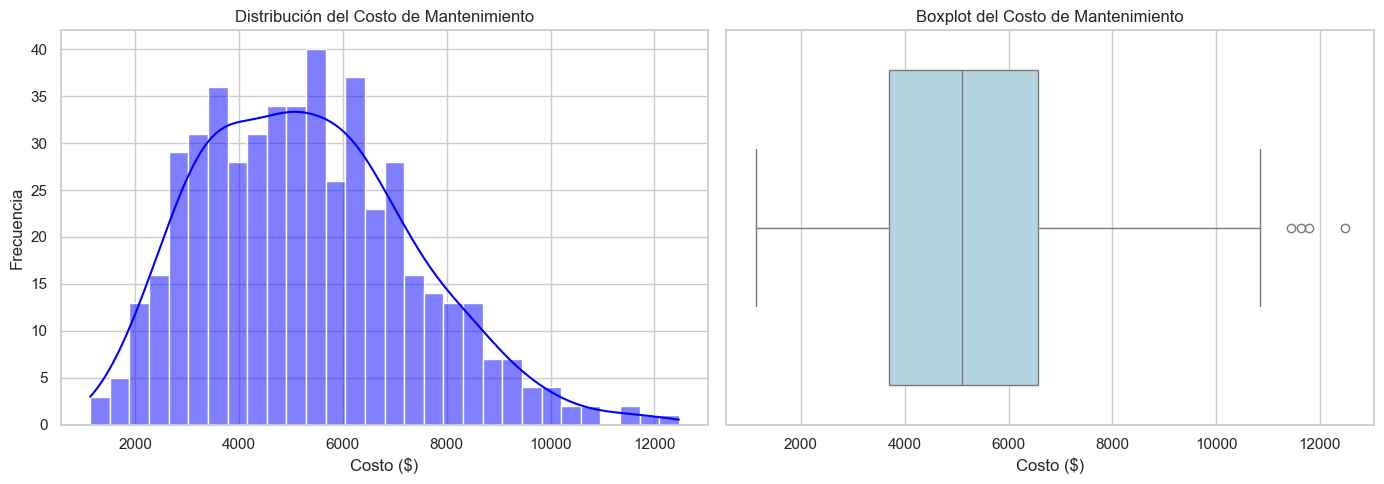

Coeficiente de Asimetría (Skewness): 0.5091
Nota: Un valor > 1 indica una asimetría positiva (cola hacia la derecha) considerable.


In [24]:
# Configurar la figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histograma con curva de densidad (KDE)
sns.histplot(df_mantenimiento['costo_mantenimiento'], kde=True, ax=axes[0], color='blue', bins=30)
axes[0].set_title('Distribución del Costo de Mantenimiento')
axes[0].set_xlabel('Costo ($)')
axes[0].set_ylabel('Frecuencia')

# 2. Boxplot para ver valores atípicos
sns.boxplot(x=df_mantenimiento['costo_mantenimiento'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot del Costo de Mantenimiento')
axes[1].set_xlabel('Costo ($)')

plt.tight_layout()
plt.show()

# Calcular el coeficiente de asimetría (Skewness)
asimetria = df_mantenimiento['costo_mantenimiento'].skew()
print(f"Coeficiente de Asimetría (Skewness): {asimetria:.4f}")
print("Nota: Un valor > 1 indica una asimetría positiva (cola hacia la derecha) considerable.")

El histograma muestra una distribución con forma de campana relativamente simétrica, sin una cola derecha pronunciada. El boxplot confirma que, aunque existen algunos valores atípicos en la parte superior, no representan una distorsión extrema de los datos.

El coeficiente de asimetría (*skewness*) es de **0.5091**. En estadística, valores de asimetría entre -0.5 y 0.5 indican una distribución aproximadamente simétrica. Un valor de 0.5091 representa una asimetría positiva muy leve.

Dado que la asimetría no es severa (no supera el valor de 1 o 2), **decidimos NO aplicar la transformación logarítmica**. 
Aplicar logaritmos a una distribución que ya es razonablemente simétrica podría "sobrecorregir" los datos, introduciendo una asimetría negativa artificial y complicando innecesariamente la interpretación de los coeficientes económicos. Por lo tanto, estimaremos nuestro modelo MCO utilizando el `costo_mantenimiento` en su escala original.

### **1.3. Análisis cualitativo de interacciones operativas entre las variables independientes**

Antes de estimar nuestro modelo de regresión, evaluaremos desde una perspectiva logica qué interacciones entre las variables independientes tienen sentido económico para **CargaNacional S.A.**. Una interacción nos permite capturar "efectos cruzados", donde el impacto de un factor sobre el costo de mantenimiento depende de la condición de otro factor.

**1. Interacción `km_recorridos` $\times$ `tipo_ruta_Urbana`:**
* **Hipótesis de Negocio:** El desgaste del vehículo por cada kilómetro adicional recorrido no es constante. Un kilómetro en una ruta urbana y una rural podría generar un desgaste mecánico distinto.

**2. Interacción `edad_meses` $\times$ `plan_preventivo_Si`:**
* **Hipótesis de Negocio:** Es natural que los camiones más antiguos requieran más mantenimiento correctivo. Sin embargo, el objetivo del nuevo programa de mantenimiento preventivo estricto debería ser mitigar este deterioro. Por lo tanto, el efecto de la edad sobre el costo de reparación debería ser distinto (idealmente menor) para los camiones que sí están en el plan preventivo comparado con los que no lo están. Se esperaría que el plan preventivo amortigüe el incremento de costos asociado al envejecimiento de la flota.

**3. Interacción `carga_promedio` $\times$ `tipo_ruta_Urbana`:**
* **Hipótesis de Negocio:** Transportar cargas pesadas exige más al motor y a la transmisión, pero hacerlo en una ciudad con topografía variable o semáforos multiplica ese esfuerzo en comparación con una autopista plana. No obstante, aunque tiene sentido, ya vimos que `carga_promedio` y `km_recorridos` tienen una correlación alta. Para mantener el modelo simple y evitar inducir multicolinealidad a través de los términos interactivos, priorizaremos la interacción de `tipo_ruta_Urbana` con `km_recorridos`.


Adicionalmente, el mapa de calor de las correlaciones nos indicó que las variables categóricas (`tipo_ruta_Urbana` y `plan_preventivo_Si`) tienen una correlación demasiado baja (cercana a $0$) con las variables continuas (`km_recorridos`, `carga_promedio` y `edad_meses`). Esto implica que la asignación de rutas y la entrada al plan preventivo se hicieron de forma independiente al uso o edad del camión. Al ser variables "ortogonales" (independientes entre sí), incluir términos de interacción entre ellas cruzará la información sin generar problemas graves de multicolinealidad con los efectos principales. Así mismo,  La matriz muestra que la ruta urbana por sí sola tiene un efecto negativo leve ($-0.27$) en el costo total, pero el kilometraje tiene un efecto mayor ($0.62$). Al interactuarlas, nuestro modelo evaluará si ese último efecto cambia drásticamente cuando los kilómetros se hacen dentro de la ciudad. Por otro lado, la edad aumenta el costo ($0.43$) y el plan preventivo lo reduce ($-0.50$). La interacción de ambas nos permitirá cuantificar el verdadero valor del programa: ¿Logra el plan preventivo "aplanar" la curva de envejecimiento del camión?

**Conclusión:**
Basados en este análisis (lógica logística + ortogonalidad estadística en la matriz), incorporaremos en nuestro modelo inicial las interacciones `km_recorridos:tipo_ruta_Urbana` y `edad_meses:plan_preventivo_Si` para evaluar estadísticamente si estos "efectos cruzados" son significativos para explicar el costo final.

### **1.4. Modelo MCO y Validación Formal de Supuestos**

Con el respaldo de nuestro análisis exploratorio y cualitativo, procedemos a estimar el modelo de Regresión Lineal Múltiple (MCO) para explicar el `costo_mantenimiento` (en su escala original, sin transformación logarítmica).

**1. Especificación del Modelo:**
Nuestra ecuación base incluirá los efectos principales de la operación (`edad_meses`, `km_recorridos`, `carga_promedio`) y las decisiones categóricas (`tipo_ruta_Urbana`, `plan_preventivo_Si`). Adicionalmente, incorporaremos las interacciones justificadas previamente:
* `km_recorridos:tipo_ruta_Urbana`: Para medir el desgaste diferencial por kilómetro en ciudad.
* `edad_meses:plan_preventivo_Si`: Para evaluar si el plan preventivo mitiga el costo de envejecimiento de la flota.

**2. Diagnóstico Econométrico (La "Cirugía"):**
Para que nuestras conclusiones económicas sean válidas (inferencia), los residuos del modelo deben cumplir con los supuestos clásicos de Gauss-Markov. Evaluaremos:
* **Homocedasticidad (Test de Breusch-Pagan):** Verifica que la varianza de los errores sea constante. La Hipótesis Nula (H0) es que sí lo es. Buscamos un p-valor $> 0.05$.
* **Normalidad (Gráfico Q-Q):** Garantiza que la distribución de los errores se asemeje a una normal, lo cual es vital para la validez de los p-valores y los intervalos de confianza de los coeficientes.

RESUMEN DEL MODELO DE INFERENCIA (MCO)
                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.853
Model:                             OLS   Adj. R-squared:                  0.851
Method:                  Least Squares   F-statistic:                     408.9
Date:                 Fri, 27 Mar 2026   Prob (F-statistic):          1.66e-200
Time:                         12:54:37   Log-Likelihood:                -4039.1
No. Observations:                  500   AIC:                             8094.
Df Residuals:                      492   BIC:                             8128.
Df Model:                            7                                         
Covariance Type:             nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

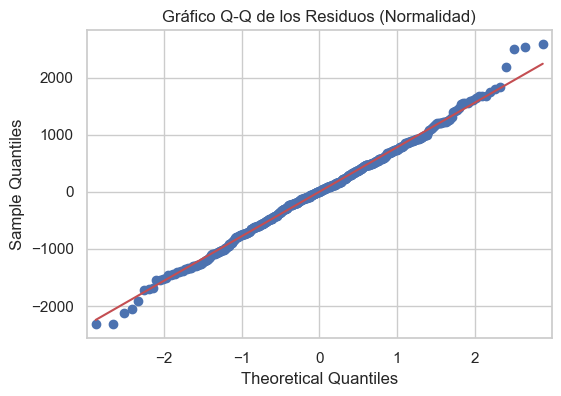

In [25]:
# ==============================================================================
# Modelo MCO Definitivo y Pruebas de Diagnóstico
# ==============================================================================

# 1. Definición de la fórmula del modelo con las dos interacciones clave
formula_mco = ("costo_mantenimiento ~ edad_meses + km_recorridos + carga_promedio + " #*Línea 1:* La variable dependiente y los efectos continuos principales
               "tipo_ruta_Urbana + plan_preventivo_Si + "                             #*Línea 2:* Los efectos categóricos (las variables *dummy*)
               "km_recorridos:tipo_ruta_Urbana + edad_meses:plan_preventivo_Si")      #*Línea 3:* Los términos de interacción.

# 2. Ajuste del modelo
modelo_mco = smf.ols(formula=formula_mco, data=df_mantenimiento).fit()

# Imprimimos el resumen detallado del modelo
print("="*85)
print("RESUMEN DEL MODELO DE INFERENCIA (MCO)")
print("="*85)
print(modelo_mco.summary())

# ==============================================================================
# Validación de Supuestos
# ==============================================================================
print("\n" + "="*85)
print("DIAGNÓSTICO DE SUPUESTOS")
print("="*85)

# Test de Breusch-Pagan para Homocedasticidad
# H0: La varianza de los residuos es constante (Homocedasticidad)
bp_test = het_breuschpagan(modelo_mco.resid, modelo_mco.model.exog)
nombres_bp = ['Estadístico LM', 'p-valor LM', 'Estadístico F', 'p-valor F']
print("Test de Breusch-Pagan (Homocedasticidad):")
for nombre, valor in zip(nombres_bp, bp_test):
    print(f"  {nombre}: {valor:.4f}")

# Gráfico Q-Q para Normalidad de los Residuos
fig, ax = plt.subplots(figsize=(6, 4))
sm.qqplot(modelo_mco.resid, line='s', ax=ax)
plt.title("Gráfico Q-Q de los Residuos (Normalidad)")
plt.show()

* **Poder Explicativo:** El modelo es altamente significativo (F-statistic p-valor cercano a 0) y tiene un **R-cuadrado ajustado de 0.851**. Esto significa que nuestras variables operativas explican el 85.1% de la variabilidad en los costos de mantenimiento, lo cual es un ajuste excelente.

* **Jarque-Bera:** El test de Jarque-Bera arrojó un p-valor de **0.252** (mayor a 0.05) y el Gráfico Q-Q muestra los puntos alineados casi perfectamente sobre la diagonal. Esto confirma que **los residuos se distribuyen de manera muy cercana a una normal**. Nuestra decisión de *no* aplicar el logaritmo a la variable dependiente fue estadísticamente adecuada.

* **Éxito del Plan Preventivo (Interacción):** Por cada mes que envejece un camión, su costo de mantenimiento correctivo aumenta en **$56.25** dólares (ceteris paribus). Sin embargo, si el camión pertenece al plan preventivo, este sobrecosto por envejecimiento se reduce drásticamente en **$41.73**. Es decir, el plan preventivo mitiga el efecto del tiempo, haciendo que el camión envejezca a un costo de solo $14.52 por mes. No obstante, el coeficiente principal de `plan_preventivo_Si` es de $-222.75$, pero su **p-valor es 0.317** (no significativo). En un modelo con términos interactivos, este coeficiente base representa el efecto del plan cuando la edad del camión es cero. Operativamente tiene sentido: un camión recién salido de fábrica (0 meses) no presenta diferencias significativas en costos correctivos, esté o no en el plan. Para el negocio, esto implica que la verdadera rentabilidad del programa no es inmediata, sino que radica en **mitigar la tasa de desgaste a lo largo del tiempo**. Esto se confirma estadísticamente al ver que el término de interacción (`edad_meses:plan_preventivo_Si`) sí es altamente significativo (p-valor = 0.000).

* **Los costos según el tipo de ruta (Interacción):**  El modelo indica que por cada 1,000 km recorridos, el costo base aumenta en **$340.22**. Así mismo que si la ruta es urbana, ese costo por kilómetro *disminuye* en **$66.72**.

* **Carga Promedio:** Cada tonelada adicional transportada incrementa los costos de mantenimiento en **$64.80**.

**Se detecta un problema de Heterocedasticidad**: El Test de Breusch-Pagan rechazó la hipótesis de homocedasticidad (p-valor = 0.0000). Esto indica que la varianza de los residuos cambia a lo largo de las observaciones (heterocedasticidad). En estas condiciones, los estimadores MCO siguen siendo insesgados (nuestra interpretación en dólares sigue siendo correcta), pero sus varianzas son incorrectas. Esto provoca que los errores estándar calculados tradicionalmente sean inválidos y, por ende, los p-valores podrían llevarnos a conclusiones falsas (como asumir que una variable es significativa cuando no lo es).

### **1.5. Corrección de Heterocedasticidad: Modelo con Errores Estándar Robustos**

Para garantizar que las conclusiones económicas de renovación de la flota de *CargaNacional S.A.* se basen en evidencia estadísticamente sólida, reestimaremos el modelo aplicando **Errores Estándar Robustos a la Heterocedasticidad (HC3)**. 
Esta técnica ajusta la matriz de varianzas y covarianzas, recalculando los errores estándar y los p-valores sin alterar la magnitud de los coeficientes, devolviéndole la validez a nuestra inferencia estadística.

In [ ]:
# ==============================================================================
# Ajuste del Modelo con Errores Estándar Robustos (HC3)
# ==============================================================================

# Reajustamos el mismo modelo, pero especificando cov_type='HC3' para corregir la heterocedasticidad
modelo_robusto = smf.ols(formula=formula_mco, data=df_mantenimiento).fit(cov_type='HC3')

# Imprimimos el nuevo resumen
print("="*85)
print("RESUMEN DEL MODELO (ERRORES ESTÁNDAR ROBUSTOS HC3)")
print("="*85)
print(modelo_robusto.summary())

RESUMEN DEL MODELO (ERRORES ESTÁNDAR ROBUSTOS HC3)
                             OLS Regression Results                            
Dep. Variable:     costo_mantenimiento   R-squared:                       0.853
Model:                             OLS   Adj. R-squared:                  0.851
Method:                  Least Squares   F-statistic:                     366.1
Date:                 Fri, 27 Mar 2026   Prob (F-statistic):          1.59e-190
Time:                         12:54:40   Log-Likelihood:                -4039.1
No. Observations:                  500   AIC:                             8094.
Df Residuals:                      492   BIC:                             8128.
Df Model:                            7                                         
Covariance Type:                   HC3                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------

Al aplicar la corrección de Errores Estándar Robustos (HC3) para lidiar con la heterocedasticidad, obtenemos nuestro modelo definitivo para la inferencia. Los resultados confirman que :

1. **Estabilidad de los Coeficientes:** Como dicta la teoría econométrica, los estimadores (el impacto en dólares) se mantuvieron exactamente iguales. Nuestra interpretación económica previa es correcta.
2. **Validez de la Inferencia (p-valores):**  al recalcular la varianza ninguna variable dejó de ser estadísticamente significativa. 
   * La interacción `km_recorridos:tipo_ruta_Urbana` mantiene su significancia con un p-valor de **0.025** (menor a 0.05).
   * La interacción `edad_meses:plan_preventivo_Si` mantiene su altísima significancia (p-valor = **0.000**).
   * Las variables de operación directa (`carga_promedio`, `km_recorridos`, `edad_meses`) continúan siendo determinantes estructurales del costo.

**Recomendación estratégica para CargaNacional S.A.:**

De esta manera, con un modelo que cumple con los supuestos mínimos para ser estadísticamente confiable (tras la corrección de errores robustos HC3), se recomienda a la dirección de finanzas tomar las siguientes acciones:

1. **Expandir el Plan Preventivo:** Es una inversión altamente rentable porque amortigua significativamente el encarecimiento por desgaste que sufren los camiones al envejecer. El modelo demuestra que, mientras un camión convencional incrementa sus costos de mantenimiento en **$56.26** por cada mes de edad, pertenecer al programa preventivo reduce este sobrecosto mensual en **$41.74**. Esto significa que los vehículos en el plan envejecen a una fracción del costo (solo $14.52 adicionales por mes).
2. **Priorizar la renovación y asignación en Larga Distancia:** Dado que el desgaste por cada 1,000 kilómetros recorridos es estadísticamente más costoso en rutas de larga distancia (**$340.23** de incremento base) que en entornos urbanos (donde el costo disminuye en **$66.72** por cada 1,000 km), se recomienda una política de rotación inteligente. Los camiones nuevos (menos propensos a fallas) deberían asignarse a estas rutas largas y exigentes, dejando los camiones de mayor edad para la operación en ciudad, optimizando así el costo total de la flota.

---